# Breast Cancer Classification - SVM

## Kütüphaneler

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_breast_cancer

## Fonksiyonlar

In [2]:
def load_data():
    # Bu fonksiyon veriyi yüklemek için yazıldı
    df=load_breast_cancer(as_frame=True)
    df_data=df.data
    df_data["target"]=df.target
    return df_data

In [3]:
def explore_data(df):
    # Bu fonksiyon veri keşifi için yazıldı.
    print(df.shape)
    print(df.isnull().sum().sum())
    print(df["target"].value_counts())
    return df.head()

In [4]:
def split_data(df):
     # Bu fonksiyon verinin Train / Test olarak ikiye ayrılmasını sağlar.
    X=df.drop(columns="target")
    y=df["target"]
    X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)
    return X, y, X_train, X_test, y_train, y_test

In [5]:
def build_model(X_train, y_train):
    # Bu fonksiyon model oluşturma, eğitme ve eğitilen modeli döndürme adımlarını içerir.
    my_pipe=Pipeline([
        ("Scaler", StandardScaler()),
        ("SVM", SVC())
    ])
    my_pipe.fit(X_train, y_train)
    return my_pipe

In [6]:
def evaluate_model(model, X_test, y_test):
    # Bu fonksiyon oluşturduğumuz model üzerinde tahmin yapmamızı sağlar.
    y_prediction=model.predict(X_test)
    print("Confusion Matrix", confusion_matrix(y_test, y_prediction))
    print("Accuracy Score", accuracy_score(y_test, y_prediction))
    print("Classification Report", classification_report(y_test, y_prediction))
    return y_prediction

In [7]:
def plot_confusion_matrix(y_test, y_pred):
    # Bu fonksiyon modelimizin confusion matrix değerlerini görselleştirir.
    sns.heatmap(
        confusion_matrix(y_test, y_pred),
        annot=True,
        cmap="Blues",
        fmt="d",
        xticklabels=[0,1],
        yticklabels=[0,1]
    )
    plt.title("Kanser Tespiti")
    plt.xlabel("Tahmin")
    plt.ylabel("Gerçek")
    plt.show()

In [8]:
def cross_validate_model(model, X, y):
    # Bu fonksiyon veriyi 5 defa 4 train 1 test olarak ayırır. Her seferinde farklı test grubunu kullanarak modelin başarısının tesadüf mü gerçek mi olduğunu ölçer.
    scores=cross_val_score(model, X, y, cv=5)
    for i, score in enumerate(scores,1):
        print(f"{i}. fold skoru: {score}")
    print(f"Skorların ortalaması : {scores.mean()}")
    print(f"Skorların standart sapması : {scores.std()}")     

## Lojistik Regresyon Karşılaştırması

In [9]:
def build_lr_model(X_train, y_train):
    # Lojistik Regresyon vs SVM karşılaştırması yapacağız.
    pipeline=Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression())
    ])
    pipeline.fit(X_train, y_train)
    return pipeline

## 3. Çalıştırma ve Sonuçlar

(569, 31)
0
target
1    357
0    212
Name: count, dtype: int64
Confusion Matrix [[41  2]
 [ 1 70]]
Accuracy Score 0.9736842105263158
Classification Report               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion Matrix [[41  2]
 [ 0 71]]
Accuracy Score 0.9824561403508771
Classification Report               precision    recall  f1-score   support

           0       1.00      0.95      0.98        43
           1       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



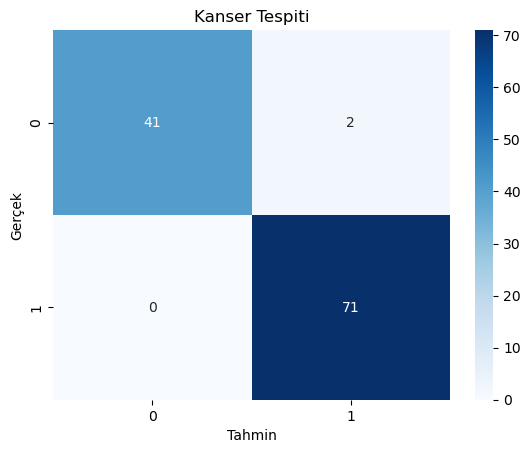

1. fold skoru: 0.9736842105263158
2. fold skoru: 0.956140350877193
3. fold skoru: 1.0
4. fold skoru: 0.9649122807017544
5. fold skoru: 0.9734513274336283
Skorların ortalaması : 0.9736376339077782
Skorların standart sapması : 0.014678541667933545


In [10]:
if __name__=="__main__":
    df=load_data()
    explore_data(df)
    X, y, X_train, X_test, y_train, y_test=split_data(df)
    my_model=build_model(X_train, y_train)
    my_lr_model=build_lr_model(X_train, y_train)
    y_lr_pred=evaluate_model(my_lr_model, X_test, y_test)
    y_pred=evaluate_model(my_model, X_test, y_test)
    plot_confusion_matrix(y_test, y_pred)
    cross_validate_model(my_model, X, y)